Лаб №3.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
df = pd.read_csv('/content/drive/MyDrive/paddydataset.csv')
print("Информация о датасете:")
df.head()

Информация о датасете:


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


Пункт 1. Анализ

Целевая переменная: 'Paddy yield(in Kg)'

Статистическое описание числовых признаков:


,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,...,Inst Wind Speed_D1_D30(in Knots),Inst Wind Speed_D31_D60(in Knots),Inst Wind Speed_D61_D90(in Knots),Inst Wind Speed_D91_D120(in Knots),Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
count,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,...,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00
mean,3.72,92.94,46.47,74.35,3.72,148.70,7.43,100.85,38.59,55.76,...,7.23,8.51,8.17,9.45,76.26,87.59,85.16,83.86,335.51,22517.73
std,1.44,35.94,17.97,28.76,1.44,57.51,2.88,39.01,14.92,21.57,...,2.57,3.20,1.99,2.52,8.00,6.78,3.49,3.13,134.31,9199.66
min,1.00,25.00,12.50,20.00,1.00,40.00,2.00,27.13,10.38,15.00,...,4.00,4.00,4.00,6.00,64.60,78.00,81.00,79.00,80.00,5410.00
25%,3.00,75.00,37.50,60.00,3.00,120.00,6.00,81.39,31.14,45.00,...,4.00,6.00,8.00,6.00,72.00,80.00,83.00,81.00,240.00,16389.00
50%,4.00,100.00,50.00,80.00,4.00,160.00,8.00,108.52,41.52,60.00,...,8.00,10.00,8.00,10.00,72.70,91.00,84.00,84.00,360.00,24636.00
75%,5.00,125.00,62.50,100.00,5.00,200.00,10.00,135.65,51.90,75.00,...,10.00,12.00,10.00,12.00,85.00,95.00,88.00,87.00,450.00,31035.00
max,6.00,150.00,75.00,120.00,6.00,240.00,12.00,162.78,62.28,90.00,...,10.00,12.00,10.00,12.00,88.50,96.00,92.00,88.00,600.00,38814.00


КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (Урожайность риса)

Топ-10 признаков, наиболее коррелирующих с урожайностью:
Urea_40Days                  0.995
Hectares                     0.995
LP_nurseryarea(in Tonnes)    0.995
Weed28D_thiobencarb          0.995
Potassh_50Days               0.995
DAP_20days                   0.995
Nursery area (Cents)         0.995
Micronutrients_70Days        0.995
LP_Mainfield(in Tonnes)      0.995
Seedrate(in Kg)              0.995
Name: Paddy yield(in Kg), dtype: float64

Топ-10 признаков с отрицательной корреляцией:
Relative Humidity_D1_D30     -0.016
Max temp_D31_D60             -0.011
Max temp_D1_D30              -0.010
51_70AI(in mm)               -0.008
Relative Humidity_D61_D90    -0.007
Relative Humidity_D91_D120   -0.007
30DRain( in mm)              -0.007
30_50DAI(in mm)              -0.002
71_105DAI(in mm)             -0.002
30_50DRain( in mm)            0.002
Name: Paddy yield(in Kg), dtype: float64


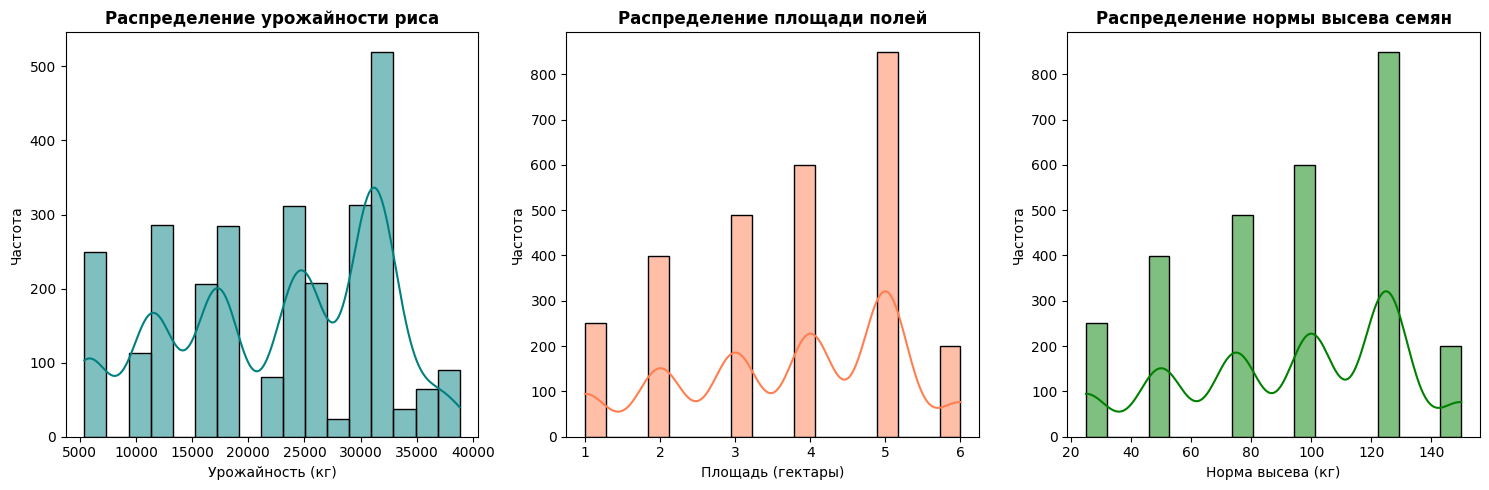

In [17]:
target_col = None
for col in df.columns:
    if 'yield' in col.lower() or 'Paddy' in col:
        target_col = col
        break

if target_col is None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    target_col = numeric_cols[-1]
print(f"Целевая переменная: '{target_col}'")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

correlations = df[numeric_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=False)

print("\nСтатистическое описание числовых признаков:")
display(df[numeric_cols + [target_col]].describe().round(2))

print("КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (Урожайность риса)")
print("\nТоп-10 признаков, наиболее коррелирующих с урожайностью:")
print(df[numeric_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=False).round(3).head(10))

print("\nТоп-10 признаков с отрицательной корреляцией:")
print(df[numeric_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=True).round(3).head(10))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df[target_col], kde=True, color='teal', ax=axes[0])
axes[0].set_title(f'Распределение урожайности риса', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Урожайность (кг)', fontsize=10)
axes[0].set_ylabel('Частота', fontsize=10)

if 'Hectares ' in df.columns:
    sns.histplot(df['Hectares '], kde=True, color='coral', ax=axes[1])
    axes[1].set_title('Распределение площади полей', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Площадь (гектары)', fontsize=10)
    axes[1].set_ylabel('Частота', fontsize=10)

if 'Seedrate(in Kg)' in df.columns:
    sns.histplot(df['Seedrate(in Kg)'], kde=True, color='green', ax=axes[2])
    axes[2].set_title('Распределение нормы высева семян', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Норма высева (кг)', fontsize=10)
    axes[2].set_ylabel('Частота', fontsize=10)

plt.tight_layout()
plt.show()

Пункт 2. Обучение

In [20]:
target_col = None
for col in df.columns:
    if 'yield' in col.lower() or 'Paddy' in col:
        target_col = col
        break

if target_col is None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    target_col = numeric_cols[-1]

print(f"Целевая переменная: '{target_col}'")

y = df[target_col]

text_columns = ['Agriblock', 'Variety', 'Soil Types', 'Nursery',
                'Wind Direction_D1_D30', 'Wind Direction_D31_D60',
                'Wind Direction_D61_D90', 'Wind Direction_D91_D120']

columns_to_drop = [target_col] + [col for col in text_columns if col in df.columns]
X = df.drop(columns=columns_to_drop, axis=1)

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"Признаки: {X.columns.tolist()[:5]}...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nМасштабированные данные готовы для моделирования!")

Целевая переменная: 'Paddy yield(in Kg)'
Размер X: (2789, 36)
Размер y: (2789,)
Признаки: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)']...

X_train shape: (2231, 36)
X_test shape: (558, 36)
y_train shape: (2231,)
y_test shape: (558,)

Масштабированные данные готовы для моделирования!


In [21]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
}

results = []

for name, model in models.items():
    if "Linear" in name or "Ridge" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'R²': round(r2, 4)
    })
    print(f"\n{name}")
    print(f"  MAE  = {mae:.3f}")
    print(f"  RMSE = {rmse:.3f}")
    print(f"  R²   = {r2:.4f}")

results_df = pd.DataFrame(results)
print("\nСравнение моделей:")
display(results_df)


Linear Regression
  MAE  = 703.286
  RMSE = 932.060
  R²   = 0.9893

Ridge Regression
  MAE  = 703.229
  RMSE = 932.153
  R²   = 0.9893

Random Forest
  MAE  = 591.472
  RMSE = 829.184
  R²   = 0.9915

Сравнение моделей:


,Model,MAE,RMSE,R²
0,Linear Regression,703.286,932.060,0.9893
1,Ridge Regression,703.229,932.153,0.9893
2,Random Forest,591.472,829.184,0.9915


Пункт 3. Визуализация


Лучшая модель по R²: Random Forest


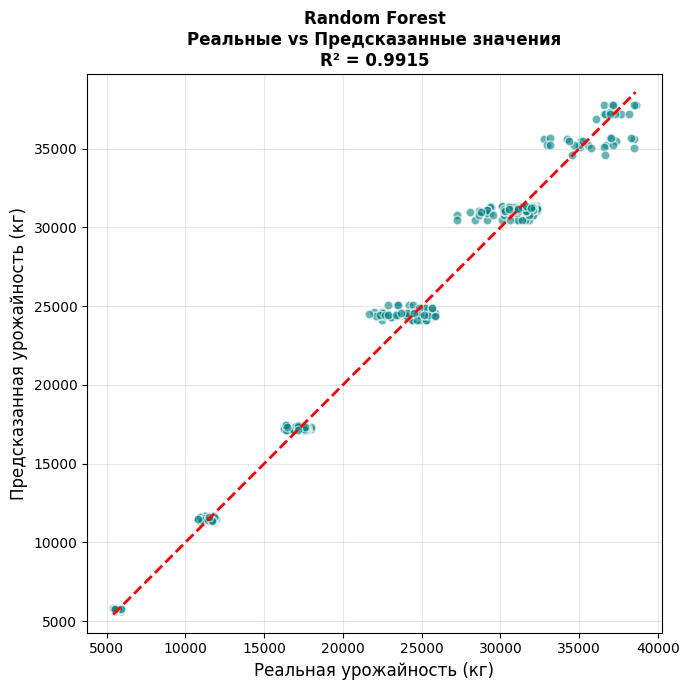


Наиболее важный признак: Micronutrients_70Days
Корреляция с урожайностью: 0.995


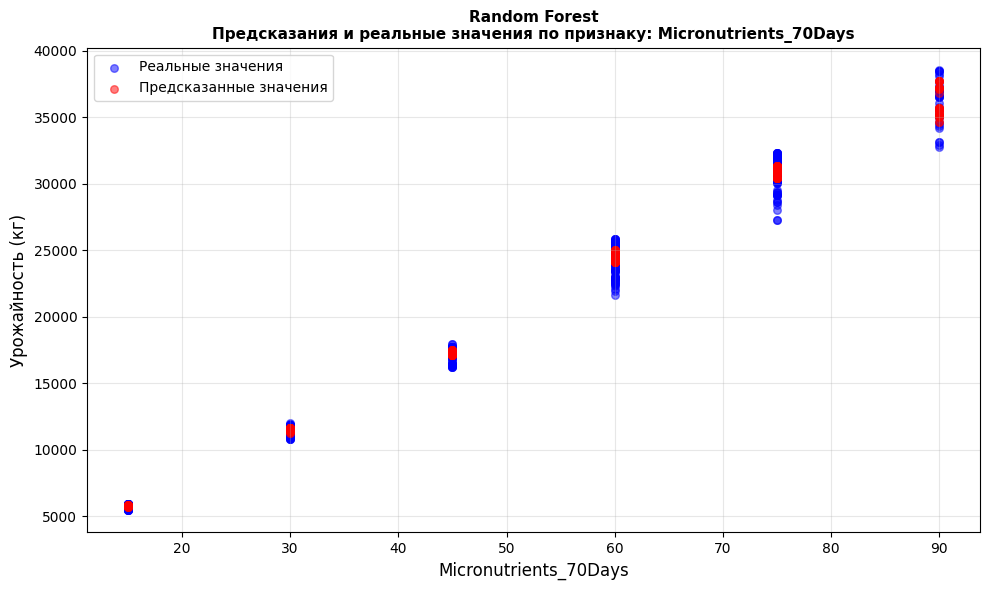

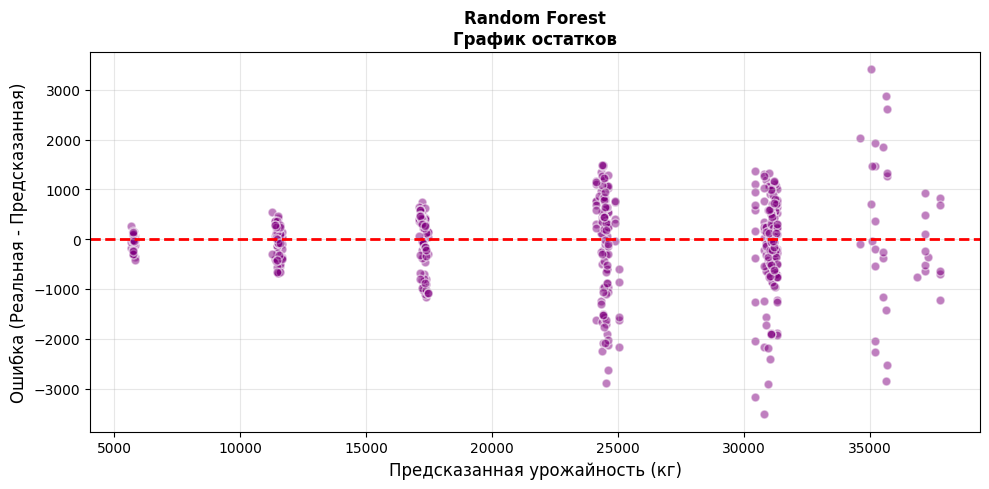

МЕТРИКИ ЛУЧШЕЙ МОДЕЛИ: Random Forest
R² (коэффициент детерминации): 0.9915
RMSE (среднеквадратичная ошибка): 829.18 кг
MAE (средняя абсолютная ошибка): 591.47 кг
MAPE (средняя абсолютная процентная ошибка): 2.64%


In [25]:
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"\nЛучшая модель по R²: {best_model_name}")

if "Forest" in best_model_name or "Gradient" in best_model_name or "XGB" in best_model_name:
    best_model = models['Random Forest'] if "Forest" in best_model_name else models.get(best_model_name)
    y_pred_best = best_model.predict(X_test)
else:
    best_model = models[best_model_name]
    if hasattr(X_test, 'columns') and 'scaler' in locals():
        X_test_scaled = scaler.transform(X_test)
        y_pred_best = best_model.predict(X_test_scaled)
    else:
        y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='teal', edgecolor='white', s=40)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная урожайность (кг)', fontsize=12)
plt.ylabel('Предсказанная урожайность (кг)', fontsize=12)
plt.title(f'{best_model_name}\nРеальные vs Предсказанные значения\nR² = {r2_score(y_test, y_pred_best):.4f}',
          fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

target_col = 'Paddy yield(in Kg)'
if target_col not in df.columns:
    for col in df.columns:
        if 'yield' in col.lower():
            target_col = col
            break

numeric_cols = X_train.select_dtypes(include=[np.number]).columns
correlations = pd.Series(index=numeric_cols)
for col in numeric_cols:
    if col in X_train.columns:
        correlations[col] = np.corrcoef(X_train[col], y_train)[0, 1]

most_important_feature = correlations.abs().idxmax()
print(f"\nНаиболее важный признак: {most_important_feature}")
print(f"Корреляция с урожайностью: {correlations[most_important_feature]:.3f}")

plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(X_test[most_important_feature])
feature_sorted = X_test[most_important_feature].iloc[sorted_idx]
y_test_sorted = y_test.iloc[sorted_idx]
y_pred_sorted = y_pred_best[sorted_idx]

plt.scatter(feature_sorted, y_test_sorted,
            color='blue', alpha=0.5, s=30, label='Реальные значения')
plt.scatter(feature_sorted, y_pred_sorted,
            color='red', alpha=0.5, s=30, label='Предсказанные значения')

plt.xlabel(most_important_feature, fontsize=12)
plt.ylabel('Урожайность (кг)', fontsize=12)
plt.title(f'{best_model_name}\nПредсказания и реальные значения по признаку: {most_important_feature}',
          fontsize=11, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

errors = y_test - y_pred_best
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_best, errors, alpha=0.5, color='purple', edgecolor='white', s=40)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Предсказанная урожайность (кг)', fontsize=12)
plt.ylabel('Ошибка (Реальная - Предсказанная)', fontsize=12)
plt.title(f'{best_model_name}\nГрафик остатков', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"МЕТРИКИ ЛУЧШЕЙ МОДЕЛИ: {best_model_name}")
print(f"R² (коэффициент детерминации): {r2_score(y_test, y_pred_best):.4f}")
print(f"RMSE (среднеквадратичная ошибка): {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f} кг")
print(f"MAE (средняя абсолютная ошибка): {mean_absolute_error(y_test, y_pred_best):.2f} кг")
print(f"MAPE (средняя абсолютная процентная ошибка): {np.mean(np.abs((y_test - y_pred_best) / y_test)) * 100:.2f}%")